In [3]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing
from concurrent.futures import ProcessPoolExecutor

# Aponta para o diretório local no teu Arch Linux
sys.path.insert(0, '/home/esdras/Wqnets/QuantumNet')
from quantumnet.topology import Network

# Configurações visuais para os gráficos do artigo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

# ===============================
# REPRODUTIBILIDADE: MAPA DE SEEDS
# ===============================
MASTER_SEED = 20260326  # data fixa do experimento (YYYYMMDD)

def _stable_int_from_key(*parts: object) -> int:
    """Gera um inteiro estável a partir de uma chave textual (independe do hash aleatório do Python)."""
    import hashlib
    key = "|".join(map(str, parts)).encode("utf-8")
    digest = hashlib.blake2b(key, digest_size=8).digest()
    return int.from_bytes(digest, "little", signed=False)

def make_seed_map():
    """Mapa fixo de seeds por experimento. Ajuste MASTER_SEED e as chaves se necessário."""
    return {
        'exp1': MASTER_SEED + 1,
        'exp2': MASTER_SEED + 2,
        'exp3': MASTER_SEED + 3,
    }

SEED_MAP = make_seed_map()

def get_rng(exp: str, *key_parts: object) -> random.Random:
    base = SEED_MAP[exp]
    seed = (base + (_stable_int_from_key(*key_parts) % 2_000_000_000)) % 2_000_000_000
    return random.Random(seed)

def seed_numpy(exp: str, *key_parts: object) -> None:
    base = SEED_MAP[exp]
    seed = (base + (_stable_int_from_key(*key_parts) % 2_000_000_000)) % 2_000_000_000
    np.random.seed(seed)

def plot_and_save(df, x_col, hue_col, exp_name):
    metrics = {
        'service_rate': 'Taxa de Atendimento',
        'denied_rate': 'Taxa de Negação',
        'avg_buffer_utilization': 'Ocupação Média do Buffer (bits)',
        'replenishment_events': 'Eventos de Reposição'
    }
    
    for metric, ylabel in metrics.items():
        plt.figure()
        if hue_col:
            sns.barplot(data=df, x=x_col, y=metric, hue=hue_col, capsize=.1, errorbar='sd')
        else:
            sns.barplot(data=df, x=x_col, y=metric, capsize=.1, errorbar='sd', color='skyblue')
            
        plt.title(f'{exp_name} - {ylabel}')
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.savefig(f'{exp_name}_{metric}.png', dpi=300)
        plt.show()
    
    csv_filename = f'{exp_name}_resultados.csv'
    df.to_csv(csv_filename, index=False)
    print(f"Resultados guardados em {csv_filename}")

A iniciar 3 tarefas do Experimento 1...


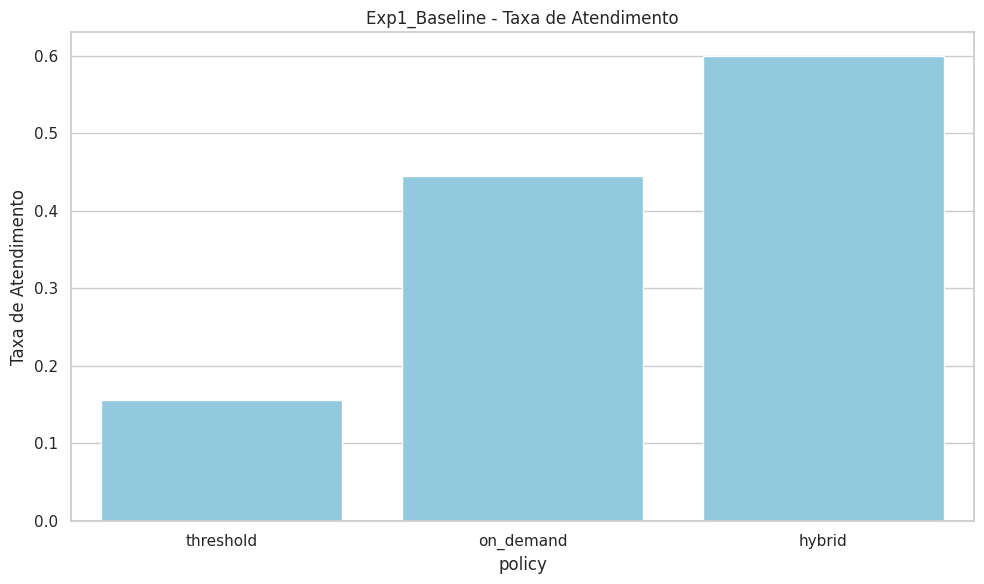

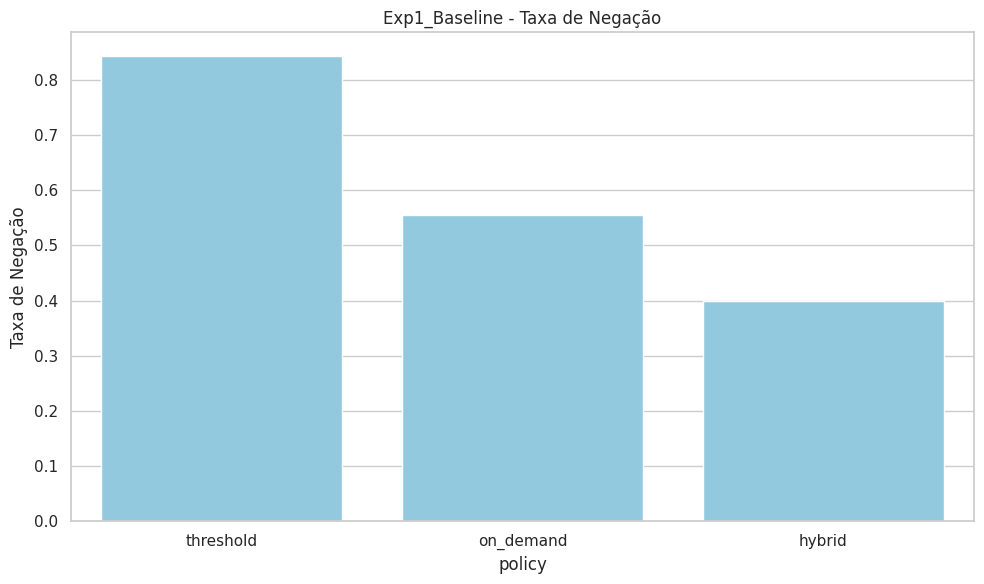

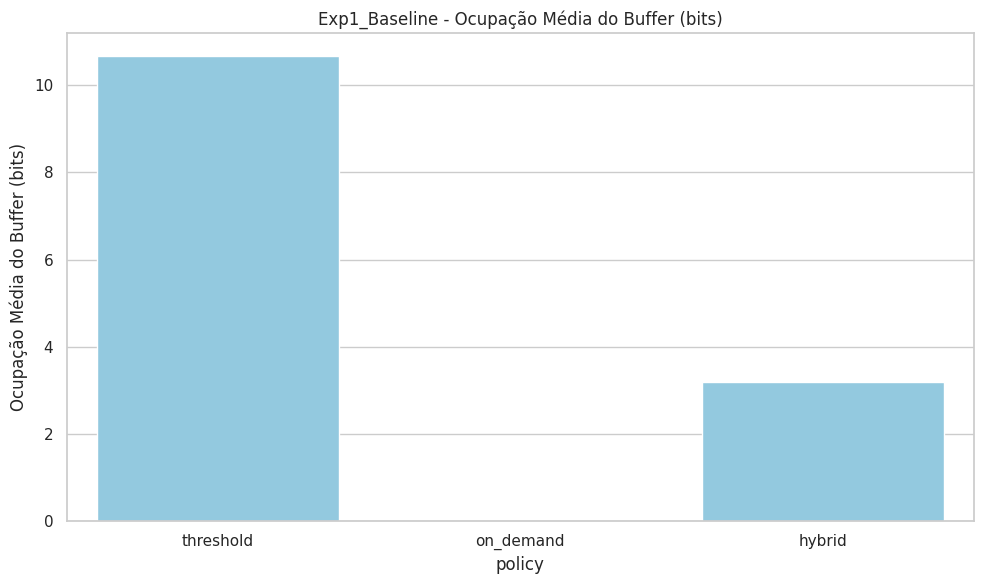

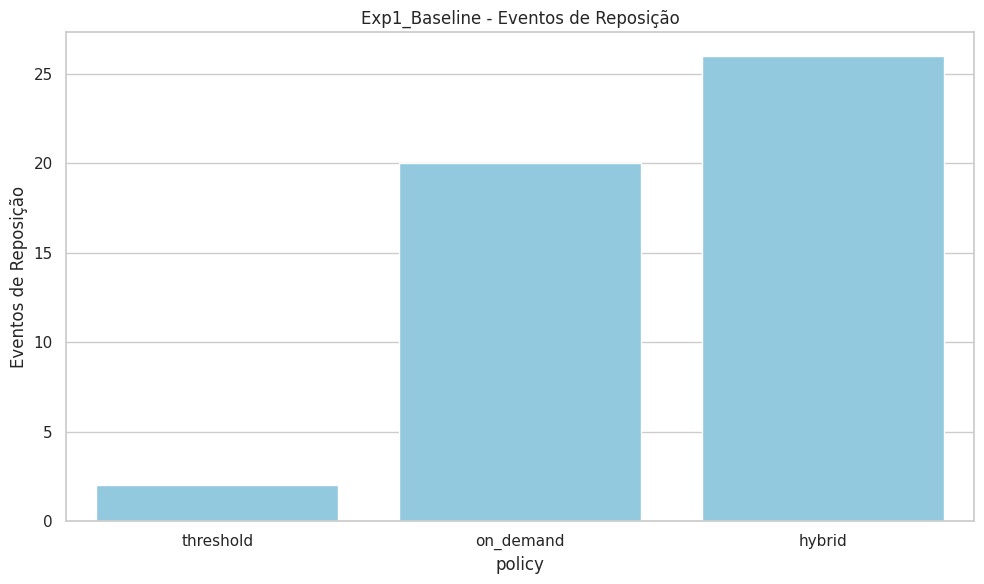

Resultados guardados em Exp1_Baseline_resultados.csv


trial     service_rate     denied_rate     replenishment_events      \
           mean std         mean std        mean std                 mean std   
policy                                                                          
hybrid      0.0 NaN        0.600 NaN       0.400 NaN                 26.0 NaN   
on_demand   0.0 NaN        0.444 NaN       0.556 NaN                 20.0 NaN   
threshold   0.0 NaN        0.156 NaN       0.844 NaN                  2.0 NaN   

          avg_buffer_utilization      
                            mean std  
policy                                
hybrid                     3.200 NaN  
on_demand                  0.000 NaN  
threshold                 10.667 NaN

In [ ]:
# ==========================================
# EXPERIMENTO 1: FUNÇÃO ISOLADA (WORKER)
# ==========================================
def run_exp1_trial(args):
    policy, trial = args
    rng = get_rng('exp1', policy, trial)
    seed_numpy('exp1', policy, trial)
    
    net = Network()
    net.set_ready_topology('Linha', 4)
    net.controller.set_policy(policy)
    
    link_pairs = [(0, 1), (1, 2), (2, 3)]
    minimum_stock_bits = 128
    requests_per_link = 15
    request_bit_options = [32, 48, 64]
    
    for a, b in link_pairs:
        net.controller.set_minimum_stock(a, b, minimum_stock_bits)
        
    buffer_history = []
    
    for a, b in link_pairs:
        for _ in range(requests_per_link):
            req_bits = rng.choice(request_bit_options)
            net.controller.handle_key_request(a, b, req_bits)
            buffer_history.append(int(net.get_qkd_link_state(a, b)['bits_available']))
            
    served, denied, replenishments = 0, 0, 0
    for a, b in link_pairs:
        state = net.get_qkd_link_state(a, b)
        served += int(state['served_requests'])
        denied += int(state['denied_requests'])
        replenishments += int(state['replenishment_events'])
        
    total_reqs = served + denied
    return {
        'policy': policy,
        'trial': trial,
        'service_rate': served / total_reqs if total_reqs > 0 else 0,
        'denied_rate': denied / total_reqs if total_reqs > 0 else 0,
        'replenishment_events': replenishments,
        'avg_buffer_utilization': np.mean(buffer_history) if buffer_history else 0
    }

# ==========================================
# EXECUÇÃO PRINCIPAL DO EXPERIMENTO 1
# ==========================================
if __name__ == '__main__':
    policies = ['threshold', 'on_demand', 'hybrid']
    trials = 1
    
    tasks = [(p, t) for p in policies for t in range(trials)]
    
    print(f"A iniciar {len(tasks)} tarefas do Experimento 1...")
    # Limite definido para 10 threads locais
    with ProcessPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(run_exp1_trial, tasks))
        
    df_exp1 = pd.DataFrame(results)
    plot_and_save(df_exp1, x_col='policy', hue_col=None, exp_name='Exp1_Baseline')
    display(df_exp1.groupby('policy').agg(['mean', 'std']).round(3))

A iniciar 9 tarefas do Experimento 2...


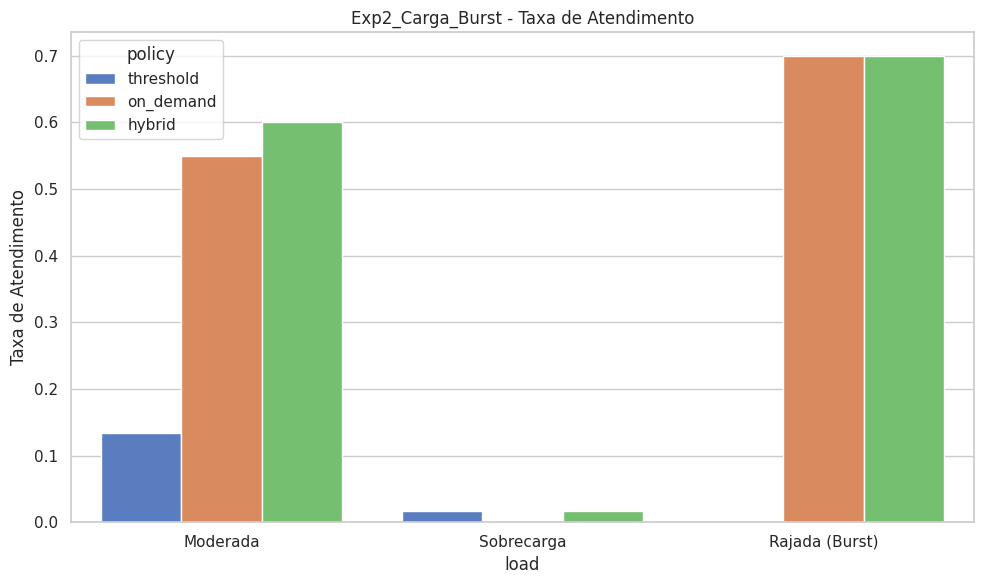

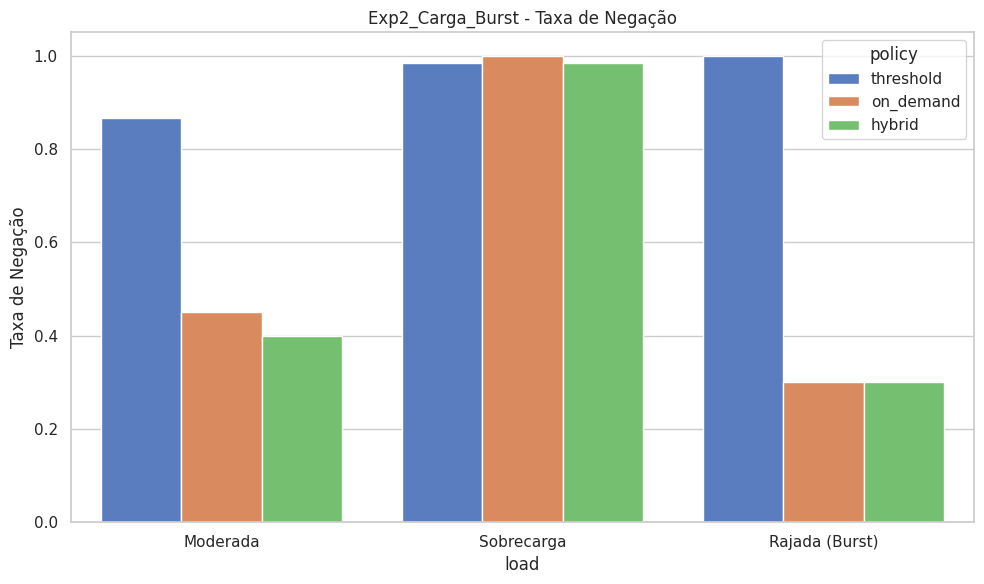

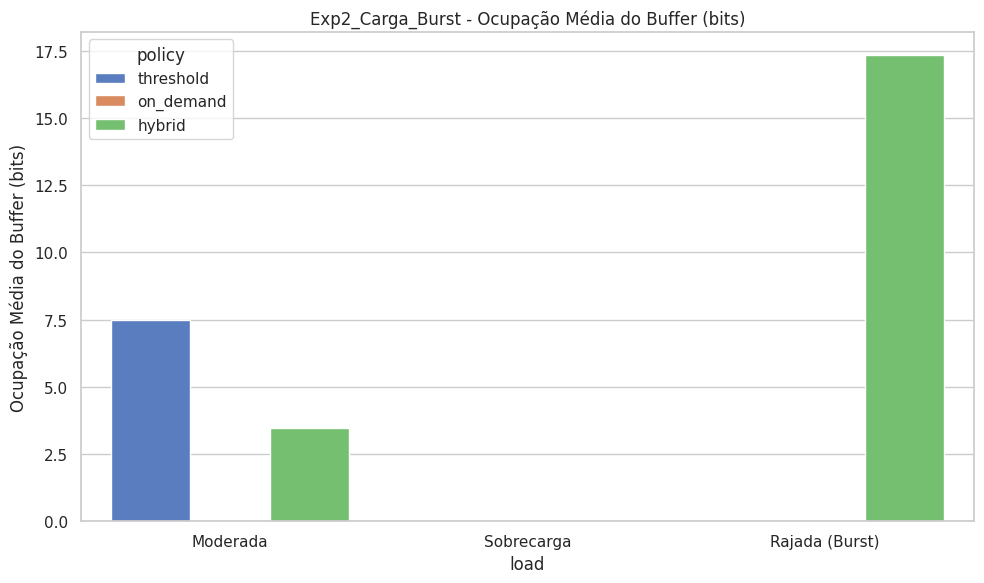

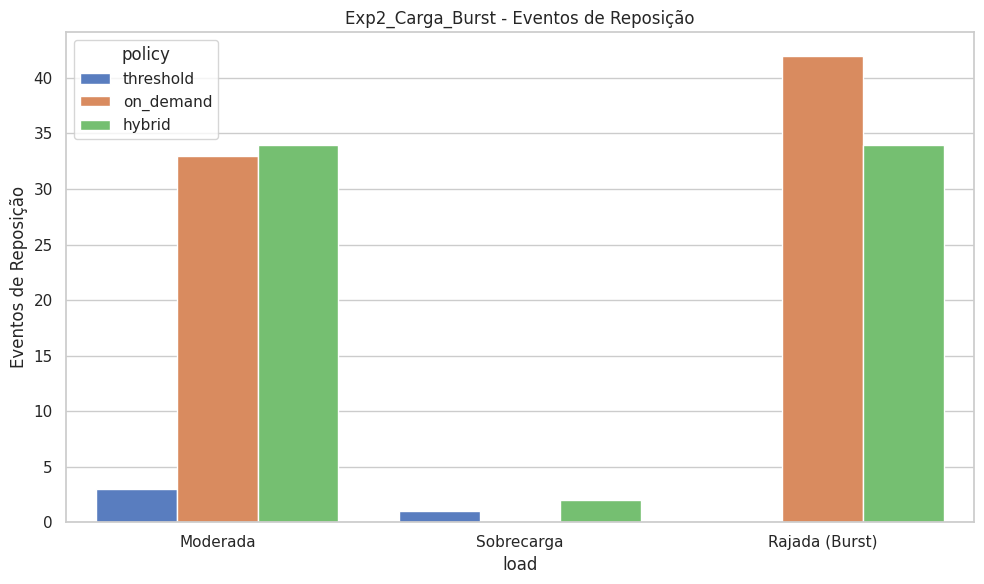

Resultados guardados em Exp2_Carga_Burst_resultados.csv


trial  service_rate  denied_rate  \
policy    load                                               
hybrid    Moderada          0.0         0.600        0.400   
          Sobrecarga        0.0         0.017        0.983   
          Rajada (Burst)    0.0         0.700        0.300   
on_demand Moderada          0.0         0.550        0.450   
          Sobrecarga        0.0         0.000        1.000   
          Rajada (Burst)    0.0         0.700        0.300   
threshold Moderada          0.0         0.133        0.867   
          Sobrecarga        0.0         0.017        0.983   
          Rajada (Burst)    0.0         0.000        1.000   

                          replenishment_events  avg_buffer_utilization  
policy    load                                                          
hybrid    Moderada                        34.0                   3.467  
          Sobrecarga                       2.0                   0.000  
          Rajada (Burst)                  34.0                  17.333  
on_demand Moderada                        33.0                   0.000  
          Sobrecarga                       0.0                   0.000  
          Rajada (Burst)                  42.0                   0.000  
threshold Moderada                         3.0                   7.467  
          Sobrecarga                       1.0                   0.000  
          Rajada (Burst)                   0.0                   0.000

In [ ]:
# ==========================================
# EXPERIMENTO 2: FUNÇÃO ISOLADA (WORKER)
# ==========================================
def run_exp2_trial(args):
    policy, load_name, pattern_type, trial = args
    rng = get_rng('exp2', policy, load_name, pattern_type, trial)
    seed_numpy('exp2', policy, load_name, pattern_type, trial)
    
    net = Network()
    net.set_ready_topology('Linha', 4)
    net.controller.set_policy(policy)
    
    link_pairs = [(0, 1), (1, 2), (2, 3)]
    minimum_stock_bits = 128
    requests_per_link = 20
    
    for a, b in link_pairs:
        net.controller.set_minimum_stock(a, b, minimum_stock_bits)
        
    buffer_history = []
    
    for a, b in link_pairs:
        for _ in range(requests_per_link):
            if pattern_type == 'moderada':
                req_bits = rng.choice([32, 48, 64])
            elif pattern_type == 'sobrecarga':
                req_bits = rng.choice([128, 192, 256])
            elif pattern_type == 'burst':
                req_bits = 512 if rng.random() > 0.8 else 16
                
            net.controller.handle_key_request(a, b, req_bits)
            buffer_history.append(int(net.get_qkd_link_state(a, b)['bits_available']))
            
    served, denied, replenishments = 0, 0, 0
    for a, b in link_pairs:
        state = net.get_qkd_link_state(a, b)
        served += int(state['served_requests'])
        denied += int(state['denied_requests'])
        replenishments += int(state['replenishment_events'])
        
    total_reqs = served + denied
    return {
        'policy': policy,
        'load': load_name,
        'trial': trial,
        'service_rate': served / total_reqs if total_reqs > 0 else 0,
        'denied_rate': denied / total_reqs if total_reqs > 0 else 0,
        'replenishment_events': replenishments,
        'avg_buffer_utilization': np.mean(buffer_history) if buffer_history else 0
    }

# ==========================================
# EXECUÇÃO PRINCIPAL DO EXPERIMENTO 2
# ==========================================
if __name__ == '__main__':
    policies = ['threshold', 'on_demand', 'hybrid']
    trials = 1
    scenarios = [('Moderada', 'moderada'), ('Sobrecarga', 'sobrecarga'), ('Rajada (Burst)', 'burst')]
    
    tasks = [(p, l_name, p_type, t) for p in policies for l_name, p_type in scenarios for t in range(trials)]
    
    print(f"A iniciar {len(tasks)} tarefas do Experimento 2...")
    with ProcessPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(run_exp2_trial, tasks))
        
    df_exp2 = pd.DataFrame(results)
    df_exp2['load'] = pd.Categorical(df_exp2['load'], categories=['Moderada', 'Sobrecarga', 'Rajada (Burst)'], ordered=True)

    plot_and_save(df_exp2, x_col='load', hue_col='policy', exp_name='Exp2_Carga_Burst')
    display(df_exp2.groupby(['policy', 'load'], observed=False).mean().round(3))

A iniciar 10 tarefas do Experimento 3...


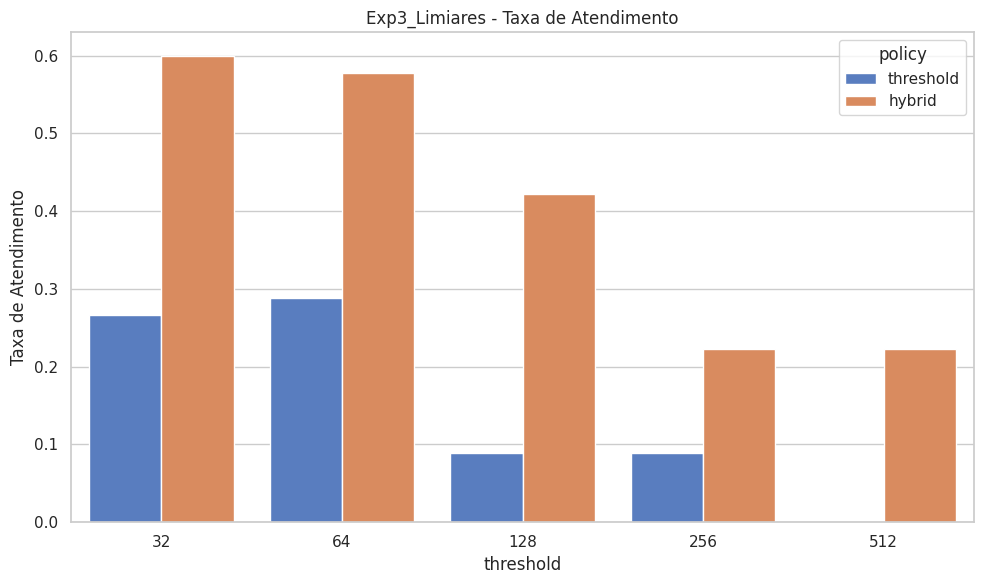

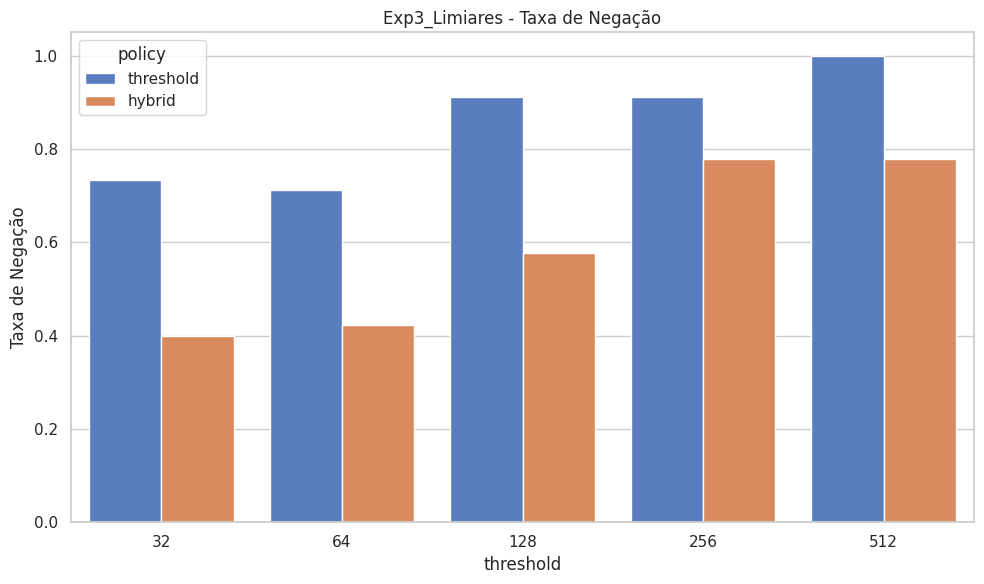

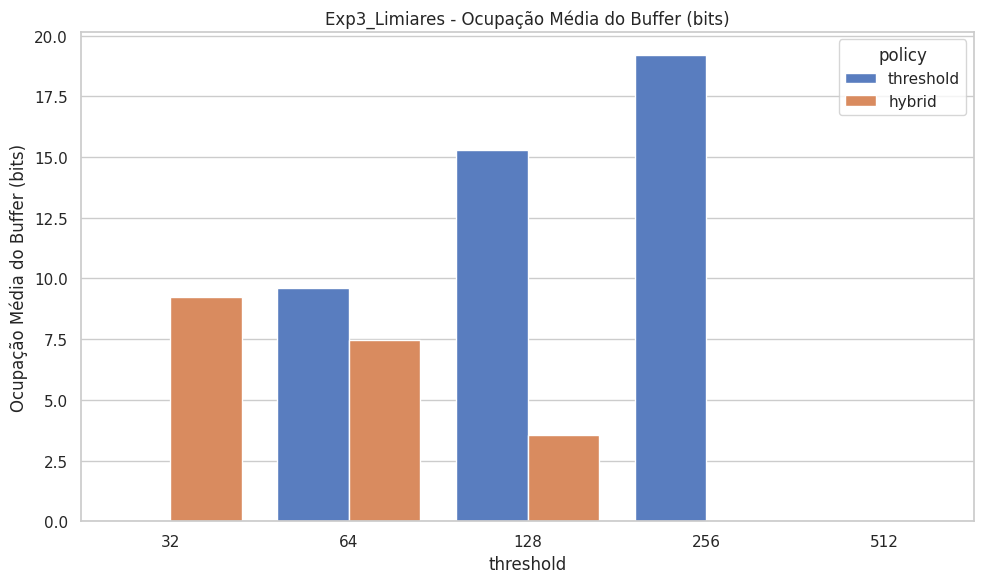

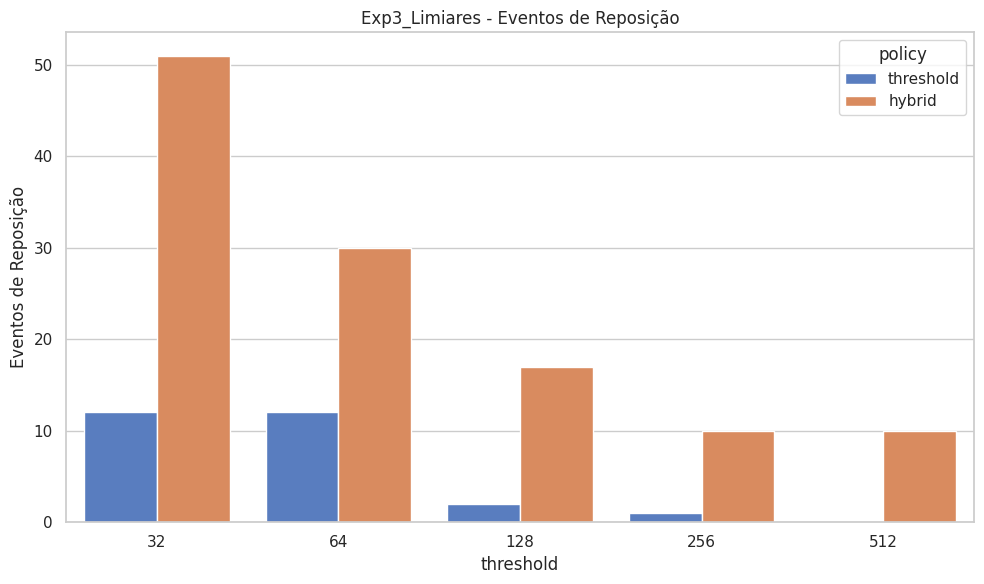

Resultados guardados em Exp3_Limiares_resultados.csv


trial  service_rate  denied_rate  replenishment_events  \
policy    threshold                                                           
hybrid    32           0.0         0.600        0.400                  51.0   
          64           0.0         0.578        0.422                  30.0   
          128          0.0         0.422        0.578                  17.0   
          256          0.0         0.222        0.778                  10.0   
          512          0.0         0.222        0.778                  10.0   
threshold 32           0.0         0.267        0.733                  12.0   
          64           0.0         0.289        0.711                  12.0   
          128          0.0         0.089        0.911                   2.0   
          256          0.0         0.089        0.911                   1.0   
          512          0.0         0.000        1.000                   0.0   

                     avg_buffer_utilization  
policy    threshold                          
hybrid    32                          9.244  
          64                          7.467  
          128                         3.556  
          256                         0.000  
          512                         0.000  
threshold 32                          0.000  
          64                          9.600  
          128                        15.289  
          256                        19.200  
          512                         0.000

In [ ]:
# ==========================================
# EXPERIMENTO 3: FUNÇÃO ISOLADA (WORKER)
# ==========================================
def run_exp3_trial(args):
    policy, threshold, trial = args
    rng = get_rng('exp3', policy, threshold, trial)
    seed_numpy('exp3', policy, threshold, trial)
    
    net = Network()
    net.set_ready_topology('Linha', 4)
    net.controller.set_policy(policy)
    
    link_pairs = [(0, 1), (1, 2), (2, 3)]
    requests_per_link = 15
    request_bit_options = [48, 64, 96]
    
    for a, b in link_pairs:
        net.controller.set_minimum_stock(a, b, threshold)
        
    buffer_history = []
    
    for a, b in link_pairs:
        for _ in range(requests_per_link):
            req_bits = rng.choice(request_bit_options)
            net.controller.handle_key_request(a, b, req_bits)
            buffer_history.append(int(net.get_qkd_link_state(a, b)['bits_available']))
            
    served, denied, replenishments = 0, 0, 0
    for a, b in link_pairs:
        state = net.get_qkd_link_state(a, b)
        served += int(state['served_requests'])
        denied += int(state['denied_requests'])
        replenishments += int(state['replenishment_events'])
        
    total_reqs = served + denied
    return {
        'policy': policy,
        'threshold': threshold,
        'trial': trial,
        'service_rate': served / total_reqs if total_reqs > 0 else 0,
        'denied_rate': denied / total_reqs if total_reqs > 0 else 0,
        'replenishment_events': replenishments,
        'avg_buffer_utilization': np.mean(buffer_history) if buffer_history else 0
    }

# ==========================================
# EXECUÇÃO PRINCIPAL DO EXPERIMENTO 3
# ==========================================
if __name__ == '__main__':
    sensitive_policies = ['threshold', 'hybrid']
    threshold_values = [32, 64, 128, 256, 512]
    trials = 1
    
    tasks = [(p, th, t) for p in sensitive_policies for th in threshold_values for t in range(trials)]
    
    print(f"A iniciar {len(tasks)} tarefas do Experimento 3...")
    with ProcessPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(run_exp3_trial, tasks))
        
    df_exp3 = pd.DataFrame(results)
    plot_and_save(df_exp3, x_col='threshold', hue_col='policy', exp_name='Exp3_Limiares')
    display(df_exp3.groupby(['policy', 'threshold']).mean().round(3))